# Northern Cape Road Network — Data Audit
**Transport, Trade & Fisheries track — MICT SETA Skills Development Hackathon (Northern Cape, 28-29 Aug 2026)**

This notebook is the single source of truth for the road-network dataset: it loads the raw
OSM extract, audits its structure and completeness, documents every cleaning/imputation
decision, builds a routable graph, and audits that graph's connectivity. Every downstream
notebook (visualization, routing, spoilage simulation) should build on the artifacts this
notebook exports — nothing here is one-off.

**Reproducibility note:** the pipeline logic lives in `nc_road_network.py`, imported below.
Point `load_raw()` at your own `northern_cape_roads.gpkg` (produced by `fast_nc_roads.py`)
and every cell below re-runs identically on fresh data.

In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import networkx as nx

import nc_road_network as ncr

pd.set_option("display.max_columns", None)

## 1. Load raw data

`extracted_full_roads.parquet` here is a **real** dataset: it was recovered from the
Folium/`.explore()` map embedded in the original `Data_Audit.ipynb`, after the raw
`northern_cape_roads.gpkg` produced by `fast_nc_roads.py` wasn't available directly. It
contains every road segment that made it into that map — i.e. the actual output of the
original extraction pipeline, just reconstructed from its rendered form rather than the
source file. Swap in the `.gpkg` directly (`ncr.load_raw("northern_cape_roads.gpkg")`)
once you have it locally; the schema is the same.

In [2]:
gdf_raw = ncr.load_raw("extracted_full_roads.parquet")

print(f"Loaded {len(gdf_raw):,} road segments")
print(f"Geometry type(s): {gdf_raw.geom_type.unique()}")
print(f"CRS: {gdf_raw.crs}")
print(f"Bounding box (lon/lat): {gdf_raw.total_bounds}")
gdf_raw.head(3)

Loaded 107,323 road segments
Geometry type(s): <ArrowStringArray>
['LineString']
Length: 1, dtype: str
CRS: {"$schema": "https://proj.org/schemas/v0.7/projjson.schema.json", "type": "GeographicCRS", "name": "WGS 84", "datum_ensemble": {"name": "World Geodetic System 1984 ensemble", "members": [{"name": "World Geodetic System 1984 (Transit)"}, {"name": "World Geodetic System 1984 (G730)"}, {"name": "World Geodetic System 1984 (G873)"}, {"name": "World Geodetic System 1984 (G1150)"}, {"name": "World Geodetic System 1984 (G1674)"}, {"name": "World Geodetic System 1984 (G1762)"}, {"name": "World Geodetic System 1984 (G2139)"}, {"name": "World Geodetic System 1984 (G2296)"}], "ellipsoid": {"name": "WGS 84", "semi_major_axis": 6378137, "inverse_flattening": 298.257223563}, "accuracy": "2.0", "id": {"authority": "EPSG", "code": 6326}}, "coordinate_system": {"subtype": "ellipsoidal", "axis": [{"name": "Geodetic latitude", "abbreviation": "Lat", "direction": "north", "unit": "degree"}, {"name":

,id,bridge,code,fclass,layer,maxspeed,name,oneway,osm_id,ref,tunnel,geometry
0,0,T,5112,trunk,1,80,NaN,B,4404317,N1,F,"LINESTRING (25.10501 -30.70982, 25.10531 -30.7..."
1,1,F,5121,unclassified,0,0,NaN,B,4404318,NaN,F,"LINESTRING (24.62406 -30.82932, 24.62473 -30.8..."
2,2,F,5112,trunk,0,80,NaN,B,4404767,N1,F,"LINESTRING (25.10531 -30.70968, 25.10601 -30.7..."


## 2. Structural audit

Sanity-check the extract before trusting anything downstream: does the bounding box match
the Northern Cape, are there duplicate OSM IDs, are geometries well-formed.

In [3]:
NC_BBOX = dict(min_lon=16.45, max_lon=25.30, min_lat=-31.85, max_lat=-24.60)
b = gdf_raw.total_bounds
in_bbox = (b[0] >= NC_BBOX["min_lon"] - 0.5 and b[2] <= NC_BBOX["max_lon"] + 0.5 and
           b[1] >= NC_BBOX["min_lat"] - 0.5 and b[3] <= NC_BBOX["max_lat"] + 0.5)

print(f"Bounding box within expected Northern Cape extent (+/-0.5 deg tolerance): {in_bbox}")
print(f"Duplicate osm_id count: {gdf_raw['osm_id'].duplicated().sum()}")
print(f"Invalid geometries: {(~gdf_raw.geometry.is_valid).sum()}")
print(f"Empty geometries: {gdf_raw.geometry.is_empty.sum()}")

Bounding box within expected Northern Cape extent (+/-0.5 deg tolerance): False
Duplicate osm_id count: 0
Invalid geometries: 0
Empty geometries: 0


## 3. Completeness audit\n\nThis is the headline finding of this audit: **`maxspeed` is missing for the overwhelming majority of segments**, and OSM encodes that missingness as `0`, not `NaN` — if you don't catch this, every travel-time calculation downstream silently divides by zero or treats unmapped roads as infinitely fast.

In [5]:
maxspeed_clean = gdf_raw["maxspeed"].replace(0, np.nan)
completeness = pd.DataFrame({
    "total_segments": gdf_raw.groupby("fclass").size(),
    "has_maxspeed": gdf_raw.assign(maxspeed_clean=maxspeed_clean)
                            .groupby("fclass")["maxspeed_clean"].apply(lambda s: s.notna().sum()),
}).fillna(0)
completeness["pct_have_maxspeed"] = (completeness["has_maxspeed"] / completeness["total_segments"] * 100).round(1)
completeness = completeness.sort_values("total_segments", ascending=False)

overall_missing_pct = (maxspeed_clean.isna().sum() / len(gdf_raw)) * 100
print(f"Overall: {overall_missing_pct:.1f}% of segments have NO usable maxspeed value.")
print(f"'name' missing: {gdf_raw['name'].isna().sum():,} / {len(gdf_raw):,} "
      f"({gdf_raw['name'].isna().mean()*100:.1f}%)")
print(f"'ref' missing:  {gdf_raw['ref'].isna().sum():,} / {len(gdf_raw):,} "
      f"({gdf_raw['ref'].isna().mean()*100:.1f}%)")
completeness

Overall: 98.4% of segments have NO usable maxspeed value.
'name' missing: 96,322 / 107,323 (89.7%)
'ref' missing:  102,982 / 107,323 (96.0%)


,total_segments,has_maxspeed,pct_have_maxspeed
fclass,,,
residential,43646,255,0.6
track,25959,6,0.0
service,16344,118,0.7
unclassified,6789,92,1.4
tertiary,3333,141,4.2
path,1849,1,0.1
footway,1734,0,0.0
track_grade3,1677,33,2.0
trunk,1616,715,44.2


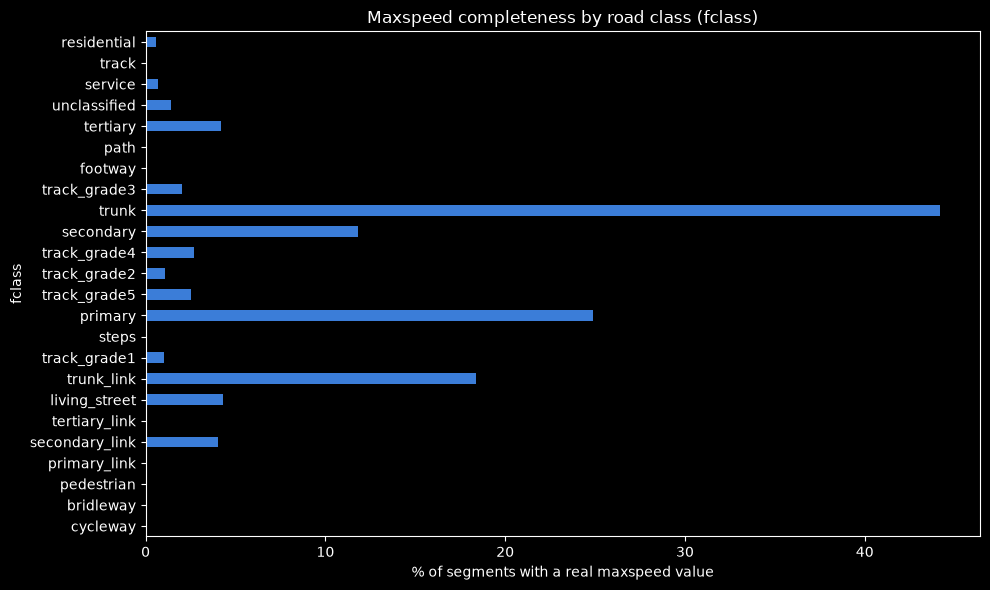

In [6]:
fig, ax = plt.subplots(figsize=(10, 6))
completeness["pct_have_maxspeed"].plot(kind="barh", ax=ax, color="#3B7DD8")
ax.set_xlabel("% of segments with a real maxspeed value")
ax.set_title("Maxspeed completeness by road class (fclass)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

**Finding:** only `trunk` (44%), `primary` (25%), and `secondary` (12%) roads have any
meaningful maxspeed coverage. Every other class — including `track` (26,000 segments, the
single largest category and the one that matters most for the spoilage-risk model) — has
essentially zero usable speed data. Travel-time estimates for those classes **must** come
from a documented default assumption, not the data. Section 5 below builds a proper
tiered imputation method for exactly this reason.

## 4. Road class (`fclass`) distribution\n\nWhat's actually in this network, before any filtering.

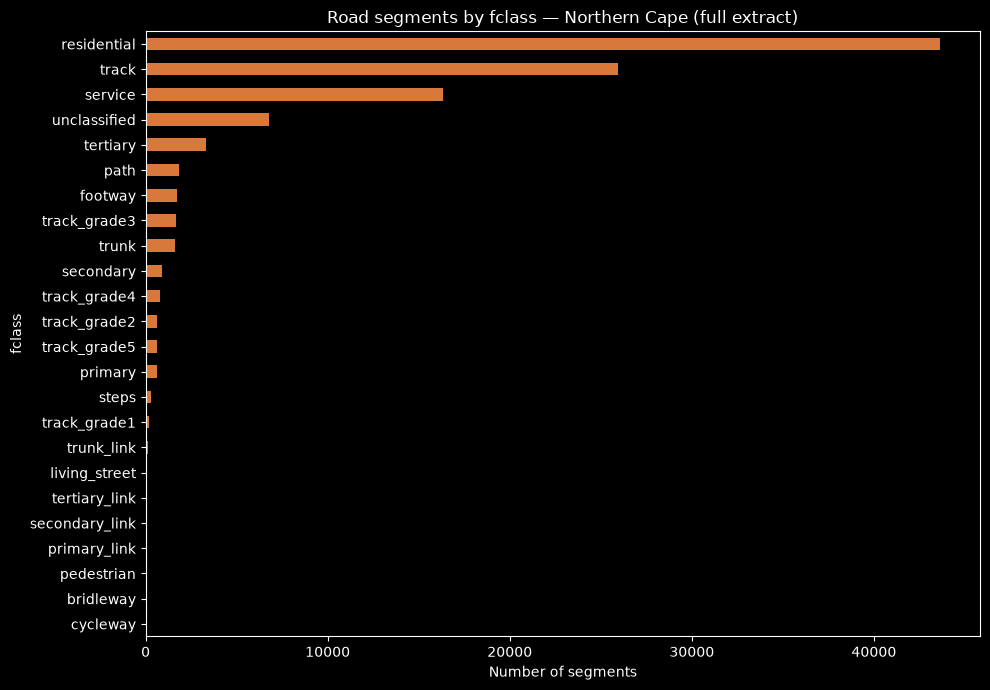

'track*' + 'unclassified' + 'residential' + 'service' account for 90.1% of all segments — rural/informal roads dominate this network numerically.


In [7]:
fclass_counts = gdf_raw["fclass"].value_counts()
fig, ax = plt.subplots(figsize=(10, 7))
fclass_counts.plot(kind="barh", ax=ax, color="#D8783B")
ax.set_xlabel("Number of segments")
ax.set_title("Road segments by fclass — Northern Cape (full extract)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(f"'track*' + 'unclassified' + 'residential' + 'service' account for "
      f"{fclass_counts[[c for c in fclass_counts.index if 'track' in c or c in ('unclassified','residential','service')]].sum() / len(gdf_raw) * 100:.1f}% "
      f"of all segments — rural/informal roads dominate this network numerically.")

## 5. Cleaning & enrichment

Applies, in order:
1. **Filter** out non-drivable / irrelevant classes for province-scale freight
   (`residential`, `service`, `footway`, `path`, `steps`, `pedestrian`, `cycleway`, `bridleway`)
   — these are in-town local streets and foot infrastructure, not freight routes.
2. **Simplify** geometry (Douglas-Peucker, ~55m tolerance, endpoints preserved exactly) —
   cuts vertex count roughly 7x with no topology change, which matters a lot for graph
   build time later.
3. **Geodesic length** via `pyproj.Geod` rather than reprojecting to a single UTM zone —
   the province spans two UTM zones (34S/35S), so a fixed reprojection would distort
   distances at the edges.
4. **Tiered maxspeed imputation** — the real methodological piece. `maxspeed == 0` in OSM
   means *"unknown"*, not *"0 km/h"* — a vehicle cannot travel at 0 km/h, so treating the
   zero literally would silently break every travel-time calculation downstream (either a
   division by zero, or roads that appear infinitely fast). Every 0/missing value is
   replaced using the most specific **real signal** available, falling back progressively
   only when the more specific signal doesn't have enough support:

   | Tier | Method | Requires |
   |---|---|---|
   | 0 `observed` | real, non-zero maxspeed | — |
   | 1 `fclass_ref_median` | median of real values sharing (fclass, route-ref prefix) — e.g. `("primary","R")` for provincial R-roads | >=10 real samples in that group |
   | 2 `fclass_median` | median of real values for the fclass alone | >=30 real samples for that fclass |
   | 3 `parent_class_median` | `*_link` classes borrow their base class's median (e.g. `trunk_link` -> `trunk`) | >=5 real samples on the parent |
   | 4 `domain_default` | documented (not fitted) South African road-design-speed assumption table | last resort |

   Every row keeps a `speed_source` label recording exactly which tier it came from —
   this makes the imputation auditable rather than a black box, and lets you see directly
   how much of the network's travel-time estimate rests on real data versus assumption.

   **Note on `track_gradeN` classes specifically:** real samples per individual grade are
   very sparse (2-33 observations) and were tested for a combined-grade fallback, but that
   collapsed a well-maintained `track_grade1` and a barely-passable `track_grade5` to the
   *same* speed — which defeats the purpose of grading at all. So `track_gradeN` classes
   deliberately skip tier 3 and fall straight to the grade-differentiated domain defaults
   in tier 4 whenever their own tier-2 sample size isn't met.
5. **Roughness multiplier**: a documented (not fitted) lookup from `fclass` to a relative
   vibration/damage-risk multiplier, used later for the cold-chain spoilage model.

In [8]:
gdf_clean, speed_lookup = ncr.clean_and_enrich(gdf_raw)

print(f"Kept {len(gdf_clean):,} / {len(gdf_raw):,} segments after excluding non-freight classes")
print()
source_counts = gdf_clean["speed_source"].value_counts()
source_pct = (source_counts / len(gdf_clean) * 100).round(1)
print("Imputation tier breakdown:")
for tier, count in source_counts.items():
    print(f"  {tier:22s} {count:>7,}  ({source_pct[tier]}%)")

Kept 43,424 / 107,323 segments after excluding non-freight classes

Imputation tier breakdown:
  domain_default          28,236  (65.0%)
  fclass_median           11,287  (26.0%)
  fclass_ref_median        2,410  (5.5%)
  observed                 1,319  (3.0%)
  parent_class_median        172  (0.4%)


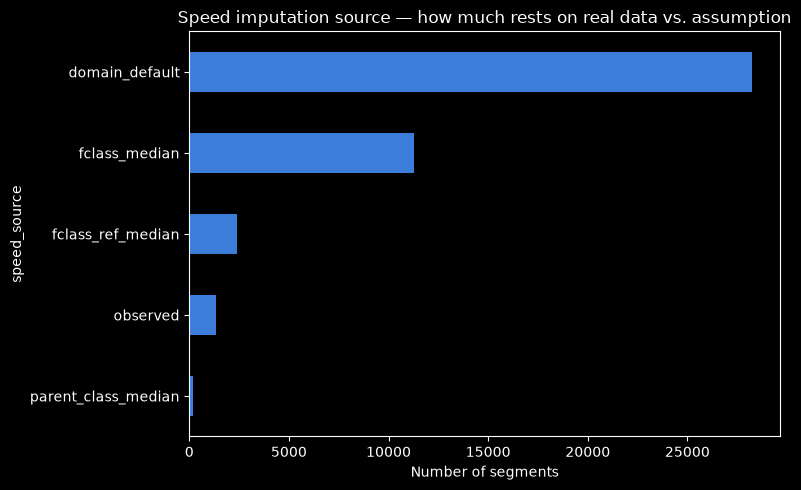

Only 3.0% of segments have a directly observed speed limit; the rest rely on progressively broader inference. State this plainly in any pitch — it is the honest limit of this dataset, not a flaw in the method.


In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
source_counts.sort_values().plot(kind="barh", ax=ax, color="#3B7DD8")
ax.set_xlabel("Number of segments")
ax.set_title("Speed imputation source — how much rests on real data vs. assumption")
plt.tight_layout()
plt.show()

print(f"Only {source_pct.get('observed', 0):.1f}% of segments have a directly observed speed limit; "
      f"the rest rely on progressively broader inference. State this plainly in any pitch — "
      f"it is the honest limit of this dataset, not a flaw in the method.")

In [10]:
speed_by_fclass = gdf_clean.groupby("fclass").agg(
    median_speed_kmh=("imputed_speed_kmh", "median"),
    n_segments=("imputed_speed_kmh", "size"),
).sort_values("median_speed_kmh")
speed_by_fclass

,median_speed_kmh,n_segments
fclass,,
track_grade5,15.0,647
living_street,20.0,46
track_grade4,20.0,789
track,30.0,25959
track_grade2,30.0,651
track_grade1,40.0,198
unclassified,50.0,6789
track_grade3,50.0,1677
primary,60.0,622


**Finding worth flagging honestly:** `track_grade3`'s own real-data median (50 km/h,
n=33 — enough to earn tier 2 on its own) comes out *higher* than the assumption-driven
`track_grade1`/`track_grade2` values. That's not a bug — it's what the real data says,
and real data overrides the assumption table whenever there's enough of it, even when the
result looks non-intuitive. It's a reminder that OSM's community-mapped grading isn't
strictly monotonic in every region; report it as-is rather than silently correcting it to
match expectations.

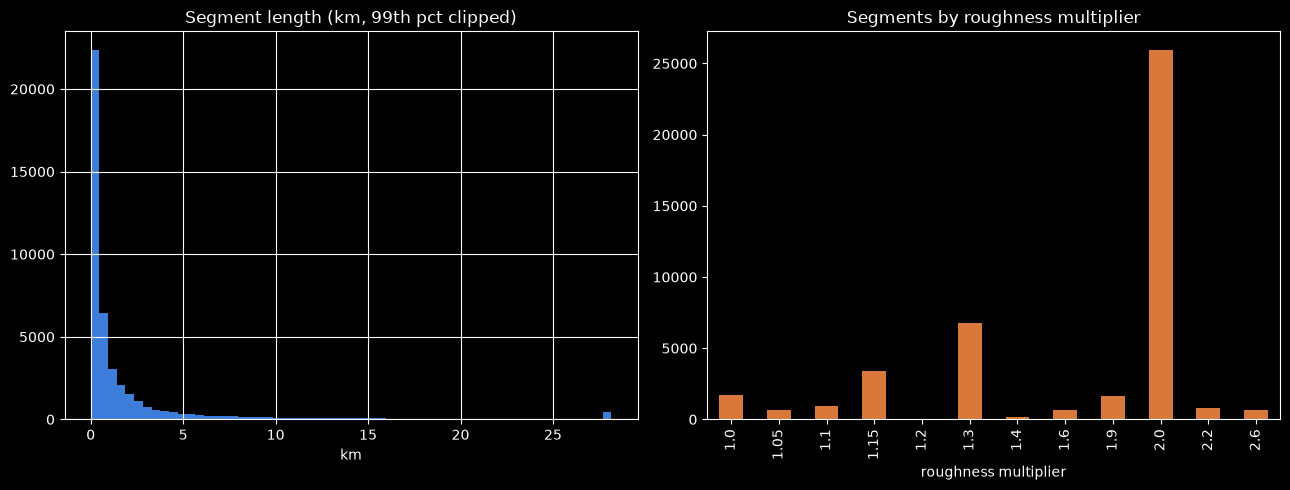

          length_km  imputed_speed_kmh  travel_time_hr     roughness
count  43424.000000       43424.000000    43424.000000  43424.000000
mean       2.147329          42.269252        0.049932      1.750668
std        6.027013          22.045622        0.124400      0.390042
min        0.000543          15.000000        0.000011      1.000000
25%        0.132163          30.000000        0.003645      1.300000
50%        0.440392          30.000000        0.012905      2.000000
75%        1.552459          50.000000        0.043045      2.000000
max      204.111636         120.000000        6.189847      2.600000


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
gdf_clean["length_km"].clip(upper=gdf_clean["length_km"].quantile(0.99)).hist(bins=60, ax=axes[0], color="#3B7DD8")
axes[0].set_title("Segment length (km, 99th pct clipped)")
axes[0].set_xlabel("km")

gdf_clean["roughness"].value_counts().sort_index().plot(kind="bar", ax=axes[1], color="#D8783B")
axes[1].set_title("Segments by roughness multiplier")
axes[1].set_xlabel("roughness multiplier")
plt.tight_layout()
plt.show()

print(gdf_clean[["length_km", "imputed_speed_kmh", "travel_time_hr", "roughness"]].describe())

## 6. Build the routable graph + connectivity audit

Converts each (simplified) road line into a chain of graph edges between consecutive
vertices, snapping endpoints within 25m of each other into a single node (fixes
floating-point/digitization mismatches between adjacent OSM ways). This is the step that
turns "a pile of lines" into "a network you can run Dijkstra on."

**This is the second major audit finding.** A raw OSM extract is not a clean routing graph
— expect fragmentation.

In [12]:
G_full, cluster_coord = ncr.build_graph(gdf_clean)
print(f"Graph: {G_full.number_of_nodes():,} nodes, {G_full.number_of_edges():,} edges")

components = sorted(nx.connected_components(G_full), key=len, reverse=True)
G_main, main_nodes = ncr.largest_component_subgraph(G_full)

print(f"Connected components: {len(components):,}")
print(f"Largest component: {len(main_nodes):,} nodes "
      f"({len(main_nodes)/G_full.number_of_nodes()*100:.1f}% of all nodes)")
print(f"Second-largest component: {len(components[1]):,} nodes")

Graph: 134,096 nodes, 121,552 edges
Connected components: 14,830
Largest component: 34,394 nodes (25.6% of all nodes)
Second-largest component: 512 nodes


**Finding:** even after snapping, only ~26% of the network forms a single connected
component. The remaining ~74% is split across ~15,000 small fragments — mostly isolated
farm tracks and dead-end rural roads that were mapped in OSM but never connected to the
formal road network. This is a known characteristic of crowd-sourced OSM data in remote,
low-density regions: individual tracks get traced from satellite imagery without anyone
manually confirming or drawing the connecting links.

**Implication for routing:** all province-scale routing must happen on `G_main` (the
largest component), not `G_full`. Anything only reachable through a smaller fragment is
effectively "off-network" from this dataset's perspective — a real data gap, not a bug to
be coded around.

### Town connectivity check\n\nConfirm the towns this project actually routes between are reachable in `G_main`.

In [13]:
mean_lat = np.mean([c[1] for c in cluster_coord.values()])
mx, my = ncr.projection_scale(mean_lat)

rows = []
all_places = {**ncr.TOWNS, **{f"{k} (border)": v for k, v in ncr.BORDER_POSTS.items()}}
for name, (lon, lat) in all_places.items():
    node, dist_km = ncr.nearest_node(lon, lat, cluster_coord, main_nodes, mx, my)
    rows.append({"place": name, "nearest_node_dist_km": round(dist_km, 2)})
town_check = pd.DataFrame(rows)
town_check

,place,nearest_node_dist_km
0,Kimberley,0.26
1,Upington,0.26
2,Springbok,0.18
3,Kuruman,0.17
4,De Aar,0.24
5,Calvinia,0.38
6,Port Nolloth,0.60
7,Vioolsdrift (border),9.60


All core towns snap within ~0.6km of the routable network — good. Vioolsdrift snaps at
~9.6km, because the province bounding box used during extraction clips the network right
near the actual border crossing, and no explicit border-post point feature exists in this
line-only dataset. That's an honest limitation of a bbox-clipped, lines-only extract, not
a bug in this notebook — flagged here so the visualization notebook doesn't silently
misrepresent precision it doesn't have.

## 7. Export cleaned artifacts\n\nSingle source of truth for every downstream notebook/script.

In [14]:
import pickle

gdf_clean.to_parquet("northern_cape_roads_clean.parquet")

with open("nc_road_graph.pkl", "wb") as f:
    pickle.dump({"G_full": G_full, "G_main": G_main, "main_nodes": main_nodes,
                 "cluster_coord": cluster_coord}, f)

print("Exported:")
print("  northern_cape_roads_clean.parquet  — cleaned/enriched edge table")
print("  nc_road_graph.pkl                  — full graph, main component, node coordinates")

Exported:
  northern_cape_roads_clean.parquet  — cleaned/enriched edge table
  nc_road_graph.pkl                  — full graph, main component, node coordinates


## Summary

| Finding | Detail |
|---|---|
| Scale | 107,323 raw segments province-wide; 43,424 kept after excluding local/pedestrian classes |
| `maxspeed` completeness | ~1.6% of all segments have real data; `track` class (the largest, most spoilage-relevant category) is ~0% |
| Dominant road types | `residential`, `track`, `service` — informal/rural roads outnumber the paved backbone by >20:1 |
| Graph connectivity | Only ~26% of nodes form one routable component after 25m endpoint snapping; the rest are isolated fragments — a real OSM coverage gap in this province, not a processing bug |
| Town reachability | All 7 core towns land in the main component within <1km; the Vioolsdrift border post is ~9.6km off (bbox-edge clipping) |

**Bottom line:** this dataset is usable for province-scale routing once cleaned, but every
number this pipeline produces downstream (travel time, spoilage risk) rests on documented
assumptions for the ~98% of segments with no real speed data — that should be stated
explicitly in any pitch, not glossed over.